# `ours` — radius-PCA, band only

**One of seven methods** in the Phase 4 comparison (`notes/dataset_plan.md` §4), and
explicitly **not claimed as a novel extractor** — the contribution is the dataset and the
comparison. This notebook is `ours`: the method from
`admittance_control` (`icp_pose_refiner_node.py`), migrated to
`scripts/baselines/radius_pca.py` and pointed at generated scenes.

**Everything is millimetres.** The ROS node works in metres, so every length constant
changed by 1000× in the move — which is why every parameter carries `_mm` and a test
asserts that a metre-scale radius finds nothing.

**This notebook runs on the balanced benchmark corpus** (`out/bench`, 50 scenes per joint
type, `balanced_corpus`). Earlier revisions ran on `out/phase3`, whose 15-butt-against-2-lap
imbalance overturned three per-type conclusions in a row.

## The line fit has been removed

On these joints the band is a **rectangle**, and a total-least-squares line through a
rectangle lands in its middle. That middle is the mid-surface between the two plates — it
is not the seam, and no amount of fitting makes it one. So `detect` returns the band and
its clusters, and nothing else. Scoring is on the point set directly (`evaluate_band`).

This reads the method honestly for what it is — a **detector**, not a localiser. The corpus
section below computes the per-type table; the shape of the result has been stable across
corpora: **recall ≈ 1,00 on every joint type** (the seam is always inside what the band
returns), precision is the cost of the band's width, and **edge is the structural outlier**
— two parallel plates have no fold, so the band covers the whole area between them.

## The validity window has been corrected since the first revision

`README §8` stated `gap + spacing < R < thickness`. The upper bound was wrong: what bridges
a plate's own two faces is the ball's **diameter**, so the bound is `R < thickness/2` — at
`R` just under `t` the neighbourhood spans nearly `2t` and a top-face point has the bottom
face inside it. `validity_window_mm` now defaults to the corrected bound, with
`upper="thickness"` keeping the original claim reachable so the correction stays
falsifiable. The paired measurement is in its own section below.

Earlier attempts to replace the estimator — ridge-following, crease projection,
direction-gated linking, DBSCAN — are **not** here. Each won on the case it targeted and
lost more elsewhere; the corpus verdicts were F1 0,64 → 0,16 and 0,64 → 0,43. They are kept
in `scratchpad/radius_pca_experimental.py`. One successor did land: **direction-aware
clustering** (`cluster_method="directional"`), measured in its own section below — real,
partial, and off by default. It is deliberately **not** applied to any `lit-*`
reimplementation; see the fidelity note there.

In [1]:
import sys
sys.path.insert(0, "..")            # notebooks/ -> weld_generator/
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from baselines import (balanced_corpus, cloud_for, detect, evaluate_band, ground_truth,
                       load_scene, scene_facts)
from baselines.radius_pca import validity_window_mm

# The BALANCED corpus: 50 scenes per joint type, one config per type. out/phase3's draw
# (15 butt, 2 lap) overturned three per-type conclusions before this existed.
CORPUS = balanced_corpus("../out/bench6a", per_type=50)
DIRS = [d for jt in ("T", "corner", "butt", "lap", "edge") for d in CORPUS[jt]]

# Density is CONTROLLED, not inherited. `density_per_mm2` is a sampled axis (0,25-4), and
# the method's own validity window has `point_spacing` in it - so running each scene at
# whatever it happened to draw would smear the density axis through every other result.
# It also bounds the cost: 400 k points at R = 5 mm is ~180 M neighbour pairs.
RHO = 0.5                    # pts/mm^2 -> mean spacing 1/sqrt(rho) = 1,41 mm
SPACING = 1.0 / np.sqrt(RHO)

print(f"{len(DIRS)} scenes: " + ", ".join(f"{k} {len(v)}" for k, v in CORPUS.items()))

250 scenes: T 50, butt 50, corner 50, edge 50, lap 50


## The runner

`R` is chosen at the **midpoint of the predicted validity window** rather than tuned. The
window is the repo's falsifiable claim, in its corrected form:

```
gap + point_spacing  <  R  <  thickness / 2
```

so picking `R` from it is what puts the claim on trial. When the window is *empty* — thin
sheet, or a gap comparable to the half-thickness — there is no valid `R` at all, and that is
a result about the method class rather than a configuration to tune away. `upper="thickness"`
selects the original (wrong) bound, kept so the correction below is a measurement and not an
assertion.

In [2]:
def run(scene_dir, view="full", noisy=False, radius_mm=None, cross_object=True,
        upper="half_thickness", directional=False, **kw):
    """One baseline run on one scene. Returns (row, result, cloud, ground truth, scene)."""
    scene, arrays = load_scene(scene_dir)
    f = scene_facts(scene)
    c = cloud_for(scene, arrays, view=view, noisy=noisy)
    if len(c["xyz"]) < 32:
        return None
    lo, hi = validity_window_mm(f["root_gap_mm"], SPACING, f["t_min_mm"], upper=upper)
    R = float(radius_mm) if radius_mm else (0.5 * (lo + hi) if lo < hi else lo)

    gt = ground_truth(scene, arrays, primary_only=True,
                      min_visible_fraction=0.1 if view == "single" else None)
    if not gt:
        return None

    if directional:
        kw = dict(kw, cluster_method="directional", tangent_radius_mm=2.0 * R,
                  max_turn_deg=30.0, lateral_link_mm=0.6 * f["t_min_mm"])
    r = detect(c["xyz"], R, object_id=c["object_id"], cross_object=cross_object,
               prefilter_density_per_mm2=RHO, **kw)
    row = {**f, "view": view, "noisy": noisy, "radius_mm": R, "upper": upper,
           "window_lo": lo, "window_hi": hi, "window_open": lo < hi,
           "used_oracle": r.used_object_oracle, "n_gt_used": len(gt),
           "n_band_raw": len(r.band_raw)}
    # Scored as a POINT SET. No line is fitted - see the header.
    row.update(evaluate_band(r.band, gt, n_clusters=r.n_clusters))
    return row, r, c, gt, scene

## One scene, in detail

The middle panel is the one to read: **the band viewed down the seam axis**. That is where
the rectangle is visible for what it is — a slab of points straddling the joint, with the
true seam marked. A line fitted through that rectangle lands in its middle, which is the
mid-surface between the two plates, not the seam. That is why the fit is gone.

3D knobs at the top of the next cell: `ZOOM` (1.0 = whole assembly, 0.12 down to individual
band points), `CENTRE`, `COLOUR_BY` (`"cluster"` or `"density"`), and `ELEV`/`AZIM`.

In [3]:
SCENE = 2
row, res, cloud, gt, scene = run(DIRS[SCENE])

print(f"{row['joint_type']} joint, quality {row['quality_level']}")
print(f"  gap {row['root_gap_mm']:.2f} mm | t_min {row['t_min_mm']:.2f} mm | "
      f"spacing {SPACING:.2f} mm")
print(f"  window {row['window_lo']:.2f} - {row['window_hi']:.2f} mm "
      f"({'OPEN' if row['window_open'] else 'CLOSED'}), using R = {row['radius_mm']:.2f} mm")
print(f"  {res.note}   oracle={res.used_object_oracle}")
print()
for k in ("n_band_points", "n_clusters", "n_gt_seams", "cluster_count_error",
          "chamfer", "pred_to_gt", "gt_to_pred", "precision", "recall", "f1",
          "lat_mean", "lat_p95", "band_width_mm"):
    v = row[k]
    print(f"  {k:<20} {v:.3f}" if isinstance(v, float) else f"  {k:<20} {v}")

T joint, quality D
  gap 0.44 mm | t_min 1.52 mm | spacing 1.41 mm
  window 1.86 - 0.76 mm (CLOSED), using R = 1.86 mm
  3 cluster(s), 114 band points from 122 above threshold   oracle=True

  n_band_points        114
  n_clusters           3
  n_gt_seams           2
  cluster_count_error  1
  chamfer              2.275
  pred_to_gt           0.726
  gt_to_pred           1.549
  precision            1.000
  recall               0.932
  f1                   0.965
  lat_mean             0.726
  lat_p95              1.554
  band_width_mm        1.321


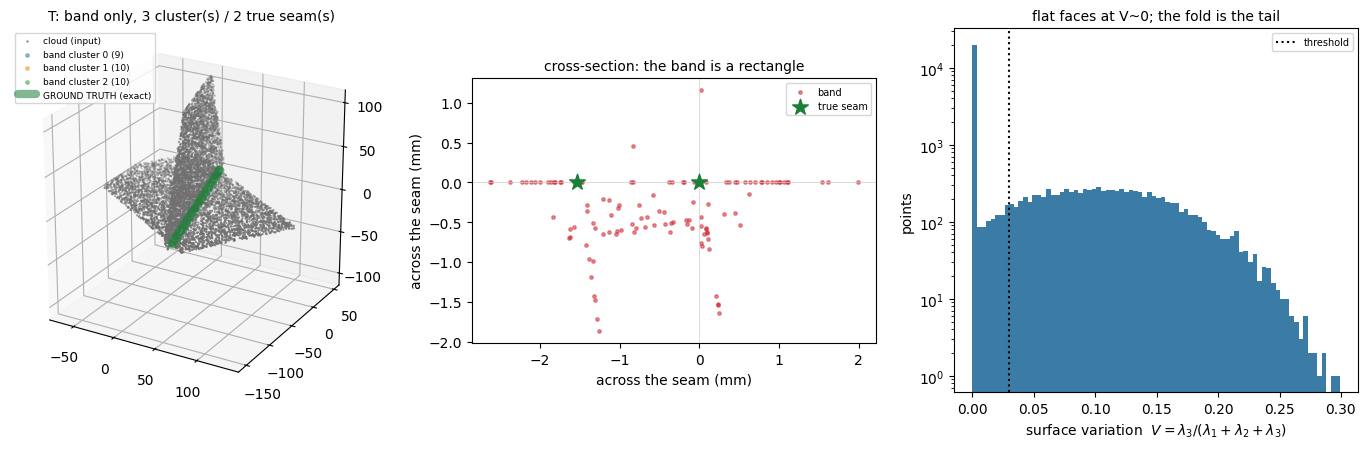

In [4]:
# --- knobs ---------------------------------------------------------------------------
ZOOM = 0.5        # 1.0 = whole assembly; 0.12 zooms right down onto the band
CENTRE = "seam"   # "seam" centres the view on the ground truth, "cloud" on the assembly
BAND_ALPHA = 0.45
COLOUR_BY = "cluster"   # "cluster" | "density"
ELEV, AZIM = 24, -60

# NO fitted line. The band and the truth, and nothing between them.
fig = plt.figure(figsize=(14, 4.6))

ax = fig.add_subplot(131, projection="3d")
pts = cloud["xyz"]
gt_pts = np.vstack(gt)
centre = gt_pts.mean(0) if CENTRE == "seam" else 0.5 * (pts.min(0) + pts.max(0))
span = float((pts.max(0) - pts.min(0)).max()) * float(ZOOM)
half = 0.55 * span
inside = np.all(np.abs(pts - centre) <= half, axis=1)
shown = pts[inside]
step = max(1, len(shown) // 7000)
ax.scatter(*shown[::step].T, s=0.3, c="#707070", label="cloud (input)")

if COLOUR_BY == "density" and len(res.band_raw):
    sc_ = ax.scatter(*res.band_raw.T, s=5, c=res.band_density, cmap="coolwarm",
                     vmin=0.4, vmax=1.4, alpha=BAND_ALPHA, depthshade=False)
    fig.colorbar(sc_, ax=ax, shrink=0.6, label="density / median")
else:
    for k in range(res.n_clusters):
        cl = res.clusters[k]
        ax.scatter(*cl.T, s=6, alpha=BAND_ALPHA, depthshade=False,
                   label=f"band cluster {k} ({len(cl)})" if k < 4 else None)
for k, g in enumerate(gt):
    ax.plot(*g.T, lw=6, c="#1a7f37", alpha=0.55, zorder=10, solid_capstyle="round",
            label="GROUND TRUTH (exact)" if k == 0 else None)

for i, setter in enumerate((ax.set_xlim, ax.set_ylim, ax.set_zlim)):
    setter(centre[i] - half, centre[i] + half)
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=ELEV, azim=AZIM)
ax.legend(fontsize=6.5, loc="upper left")
ax.set_title(f"{row['joint_type']}: band only, {res.n_clusters} cluster(s) / "
             f"{row['n_gt_seams']} true seam(s)", fontsize=10)

# The cross-section. This is where the "rectangle" is visible for what it is: the band is
# a slab straddling the joint, and any line fitted through it sits in the middle of the
# slab - the mid-surface between two plates, not on either seam.
ax2 = fig.add_subplot(132)
g0 = np.asarray(gt[0])
t = (g0[-1] - g0[0]); t /= np.linalg.norm(t)
tmp = np.array([0.0, 0.0, 1.0])
if abs(t @ tmp) > 0.9:
    tmp = np.array([1.0, 0.0, 0.0])
u = np.cross(t, tmp); u /= np.linalg.norm(u)
v = np.cross(t, u)
rel = res.band - g0[0]
ax2.scatter(rel @ u, rel @ v, s=6, c="#d1242f", alpha=0.5, label="band")
for k, g in enumerate(gt):
    rg = np.asarray(g) - g0[0]
    ax2.scatter((rg @ u).mean(), (rg @ v).mean(), s=140, marker="*", c="#1a7f37",
                zorder=5, label="true seam" if k == 0 else None)
ax2.axhline(0, c="#cccccc", lw=0.5); ax2.axvline(0, c="#cccccc", lw=0.5)
ax2.set_aspect("equal"); ax2.legend(fontsize=7)
ax2.set_xlabel("across the seam (mm)"); ax2.set_ylabel("across the seam (mm)")
ax2.set_title("cross-section: the band is a rectangle", fontsize=10)

ax3 = fig.add_subplot(133)
ax3.hist(res.variation, bins=80, color="#3a7ca5")
ax3.axvline(res.params["curvature_thresh"], c="k", ls=":", label="threshold")
ax3.set_yscale("log")
ax3.set_xlabel("surface variation  $V = \\lambda_3/(\\lambda_1+\\lambda_2+\\lambda_3)$")
ax3.set_ylabel("points")
ax3.legend(fontsize=7)
ax3.set_title("flat faces at V~0; the fold is the tail", fontsize=10)
plt.tight_layout(); plt.show()

## The validity window, on trial — both bounds

Sweep `R` across and past both windows. The claim: error should be poor below
`gap + spacing` (the ball never crosses the gap), acceptable inside, and degrade once the
**ball** bridges a plate's own two faces. The question the shading answers is *where* that
degradation starts — at `R = t` (the original claim) or at `R = t/2` (the correction, where
the ball's *diameter* reaches the thickness).

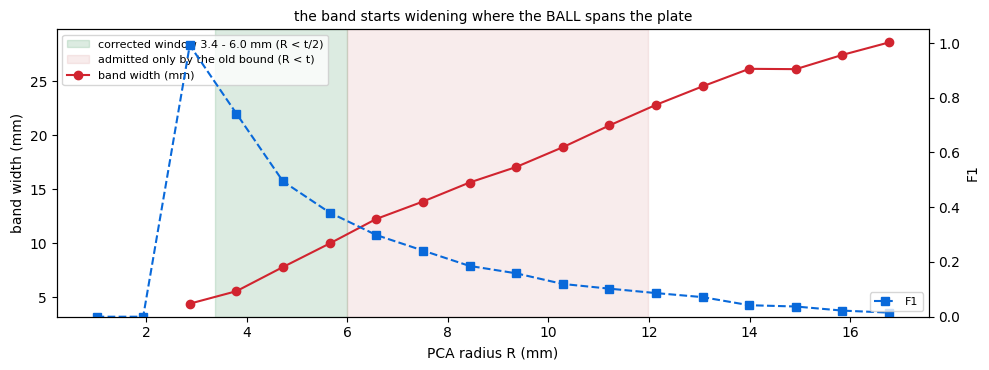

R giving within 90% of best F1: 2.87 - 2.87 mm
corrected window:               3.37 - 5.99 mm  (old upper: 11.98)


In [5]:
lo = row["window_lo"]
hi_new = row["window_hi"]                                   # corrected: t/2
hi_old = validity_window_mm(row["root_gap_mm"], SPACING, row["t_min_mm"],
                            upper="thickness")[1]           # original claim: t
radii = np.linspace(max(0.5, lo * 0.3), hi_old * 1.4, 18)
sweep = [run(DIRS[SCENE], radius_mm=float(R)) for R in radii]
chamfer = [o[0]["chamfer"] if o else np.nan for o in sweep]
f1 = [o[0]["f1"] if o else np.nan for o in sweep]
width = [o[0]["band_width_mm"] if o else np.nan for o in sweep]

fig, axa = plt.subplots(figsize=(10, 3.8))
axa.axvspan(lo, hi_new, color="#1a7f37", alpha=0.15,
            label=f"corrected window {lo:.1f} - {hi_new:.1f} mm (R < t/2)")
axa.axvspan(hi_new, hi_old, color="#c04a4a", alpha=0.10,
            label=f"admitted only by the old bound (R < t)")
axa.plot(radii, width, "o-", c="#d1242f", label="band width (mm)")
axa.set_xlabel("PCA radius R (mm)"); axa.set_ylabel("band width (mm)")
axb = axa.twinx(); axb.plot(radii, f1, "s--", c="#0969da", label="F1")
axb.set_ylabel("F1"); axb.set_ylim(0, 1.05)
axa.legend(loc="upper left", fontsize=8); axb.legend(loc="lower right", fontsize=8)
axa.set_title("the band starts widening where the BALL spans the plate", fontsize=10)
plt.tight_layout(); plt.show()

# Read F1 and width, not Chamfer: Chamfer is computed only where the method returned
# something, so it is silent about the radii where it returned nothing.
f1a = np.asarray(f1, dtype=float)
good = radii[f1a >= 0.9 * np.nanmax(f1a)] if np.isfinite(f1a).any() else np.array([])
if len(good):
    print(f"R giving within 90% of best F1: {good.min():.2f} - {good.max():.2f} mm")
    print(f"corrected window:               {lo:.2f} - {hi_new:.2f} mm  (old upper: {hi_old:.2f})")

## The corrected bound, paired on the corpus

One scene is an anecdote. The measurement: every full-view scene where **both** bounds leave
the window open, `R` at each window's midpoint, nothing else changed. Reference numbers from
the first run of this comparison (44 paired scenes): F1 0,709 → 0,897, precision
0,583 → 0,839, band width 5,70 → 3,31 mm — better in 38, 39 and 44 of 44 scenes.

The correction **closes the window on more scenes** — thin plate that had a "valid" radius
only because the bound was wrong. That is a cost of being right, and it is reported, not
hidden.

In [6]:
pair_rows = []
for d in DIRS:
    for upper in ("half_thickness", "thickness"):
        o = run(d, upper=upper)
        if o and o[0]["window_open"]:
            pair_rows.append(o[0])
pw = pd.DataFrame(pair_rows)
pw["key"] = pw.scene_id
both_open = set(pw.groupby("key").upper.nunique()[lambda s: s == 2].index)
pp = pw[pw.key.isin(both_open)]
print(f"window open under BOTH bounds in {len(both_open)} of {pw.key.nunique()} scenes "
      f"(the rest close under R < t/2 - thin plate, previously 'valid' in error)")

piv = pp.pivot_table(index="key", columns="upper",
                     values=["f1", "precision", "band_width_mm", "chamfer"])
summary = []
for m, better_high in (("f1", True), ("precision", True),
                       ("band_width_mm", False), ("chamfer", False)):
    old, new = piv[m]["thickness"], piv[m]["half_thickness"]
    imp = (new > old) if better_high else (new < old)
    summary.append({"metric": m, "R<t": old.mean(), "R<t/2": new.mean(),
                    "improved": f"{int(imp.sum())}/{len(imp)}"})
pd.DataFrame(summary).round(3)

window open under BOTH bounds in 107 of 181 scenes (the rest close under R < t/2 - thin plate, previously 'valid' in error)


,metric,R<t,R<t/2,improved
0,f1,0.705,0.871,96/107
1,precision,0.581,0.813,97/107
2,band_width_mm,6.095,4.214,102/107
3,chamfer,5.429,4.210,98/107


## The corpus

Full-visibility and single-view are evaluated **separately**, as the plan requires: a method
tuned on 360° CAD clouds is being flattered by geometry no camera returns. 250 scenes × 2
views — takes a while.

In [7]:
rows = []
for d in DIRS:
    for view in ("full", "single"):
        o = run(d, view=view)
        if o:
            rows.append(o[0])
    del o
df = pd.DataFrame(rows)
print(f"{len(df)} runs over {df.scene_id.nunique()} scenes")
print(f"validity window CLOSED in {int((~df.window_open).sum())} of {len(df)} runs "
      f"- no valid R exists for those at rho = {RHO}")
df.head(3)[["joint_type", "view", "radius_mm", "chamfer", "f1", "cluster_count_error"]]

500 runs over 250 scenes
validity window CLOSED in 286 of 500 runs - no valid R exists for those at rho = 0.5


,joint_type,view,radius_mm,chamfer,f1,cluster_count_error
0,T,full,2.885026,2.322520,0.990854,-1
1,T,single,2.885026,20.726684,0.711975,0
2,T,full,4.555078,3.658526,0.671449,-1


In [8]:
cols = ["chamfer", "lat_p95", "precision", "recall", "f1", "band_width_mm",
        "cluster_count_error"]
print("median by view\n", df.groupby("view")[cols].median().round(3), "\n")
print("median by joint type\n",
      df.groupby(["joint_type", "view"])[cols].median().round(3))

median by view
         chamfer  lat_p95  precision  recall     f1  band_width_mm  \
view                                                                
full      3.777    4.333      0.788   1.000  0.843          3.860   
single    4.237    2.230      1.000   0.872  0.824          2.201   

        cluster_count_error  
view                         
full                   -1.0  
single                  0.0   

median by joint type
                    chamfer  lat_p95  precision  recall     f1  band_width_mm  \
joint_type view                                                                
T          full      3.126    3.446      0.865   1.000  0.870          3.796   
           single    3.082    2.438      0.985   0.941  0.867          2.089   
butt       full      2.837    3.069      0.934   1.000  0.966          3.061   
           single    4.326    2.323      0.985   0.645  0.666          2.766   
corner     full      2.415    2.341      1.000   1.000  1.000          2.649   
   

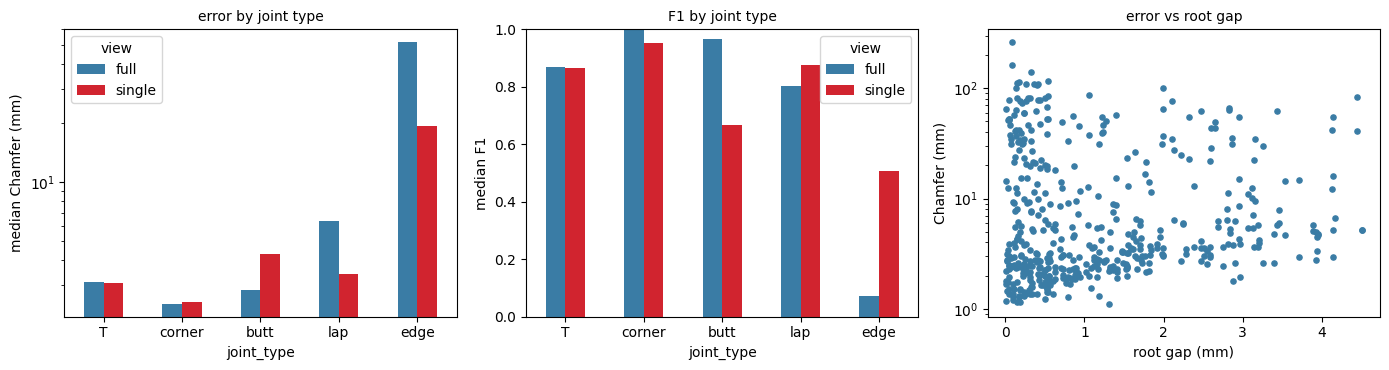

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
order = ["T", "corner", "butt", "lap", "edge"]
present = [j for j in order if j in set(df.joint_type)]

piv = df.pivot_table(index="joint_type", columns="view", values="chamfer",
                     aggfunc="median").reindex(present)
piv.plot.bar(ax=axes[0], color=["#3a7ca5", "#d1242f"], rot=0)
axes[0].set_ylabel("median Chamfer (mm)"); axes[0].set_yscale("log")
axes[0].set_title("error by joint type", fontsize=10)

df.pivot_table(index="joint_type", columns="view", values="f1",
               aggfunc="median").reindex(present).plot.bar(
    ax=axes[1], color=["#3a7ca5", "#d1242f"], rot=0)
axes[1].set_ylabel("median F1"); axes[1].set_ylim(0, 1)
axes[1].set_title("F1 by joint type", fontsize=10)

ok = df[np.isfinite(df.chamfer)]
axes[2].scatter(ok.root_gap_mm, ok.chamfer, s=14, c="#3a7ca5")
axes[2].set_xlabel("root gap (mm)"); axes[2].set_ylabel("Chamfer (mm)")
axes[2].set_yscale("log"); axes[2].set_title("error vs root gap", fontsize=10)
plt.tight_layout(); plt.show()

## Direction-aware clustering — measured, partial, off by default

Three methods in this comparison are stopped by seam *separation*: `ours` cannot split two
parallel centrelines a plate-thickness apart, `lit-regiongrow` merges both fillets or
shatters, `lit-lobb` cannot cut a closed contact perimeter. `directional_components` links
two points only when they are within `link_mm` **and the step between them runs along both
their local tangents** — a step onto a cross-run is perpendicular to the fillet it leaves,
and a step across to a parallel fillet is perpendicular to both. (Comparing the two
*tangents* to each other cuts neither: a smoothed tangent blends through a corner, and
parallel seams have identical tangents by construction.)

**Fidelity note.** This is applied to `ours` only. Neither Wei et al. nor Zhang et al.
specifies a clustering step — the standard Euclidean choice was this repo's filler — and
replacing an unspecified step with something *better* than the paper suggests would make a
reimplementation outperform the published method. A test
(`test_the_directional_switch_is_off_by_default_and_the_literature_never_sees_it`) enforces
that the `lit-*` modules never import it.

In [10]:
dir_rows = []
for jt in ("T", "corner", "butt", "lap", "edge"):
    for d in CORPUS[jt][:10]:
        for directional in (False, True):
            o = run(d, directional=directional, min_component_pts=20)
            if o:
                dir_rows.append({**o[0], "cm": "directional" if directional else "proximity"})
dd = pd.DataFrame(dir_rows)
dd["count_err"] = dd.n_clusters - dd.n_gt_seams

g = dd.groupby("cm").agg(n=("count_err", "size"),
                         exact=("count_err", lambda x: np.mean(x == 0)),
                         abs_err=("count_err", lambda x: np.mean(np.abs(x))),
                         f1=("f1", "mean"))
print(g.round(3).to_string())
print()
print(dd.groupby(["cm", "joint_type"]).agg(
    exact=("count_err", lambda x: np.mean(x == 0)),
    abs_err=("count_err", lambda x: np.mean(np.abs(x)))).round(2).to_string())
print()
print("Read this next to the window correction, because the two interact:")
print("  - under the OLD bound (R < t), directional clustering was a large win - exact seam")
print("    counts 2,3% -> 34,1% on the 44-scene paired set. The band was fat and bridged,")
print("    and direction was the only thing that could cut it.")
print("  - under the CORRECTED bound (this run's default), the band is already thin and the")
print("    gain largely evaporates - and directional over-fragments what remains, worst on")
print("    edge, whose band is a plate with no direction structure at all.")
print("The window correction absorbed most of what the clustering upgrade was worth. That")
print("is the right outcome: fix the feature before fixing the clustering. The deeper limit")
print("was never the clustering - on T joints under the old bound the band was one")
print("CONTINUOUS region, 12-19% of its points in the middle third between the fillets.")
print("No clustering finds a gap that is not there. Off by default stands.")

              n  exact  abs_err     f1
cm                                    
directional  50   0.10     4.38  0.644
proximity    50   0.08     2.30  0.644

                        exact  abs_err
cm          joint_type                
directional T             0.0      3.4
            butt          0.2      1.3
            corner        0.1      1.5
            edge          0.2     11.4
            lap           0.0      4.3
proximity   T             0.1      1.1
            butt          0.1      1.2
            corner        0.0      1.2
            edge          0.2      6.7
            lap           0.0      1.3

Read this next to the window correction, because the two interact:
  - under the OLD bound (R < t), directional clustering was a large win - exact seam
    counts 2,3% -> 34,1% on the 44-scene paired set. The band was fat and bridged,
    and direction was the only thing that could cut it.
  - under the CORRECTED bound (this run's default), the band is already thin and th

## Are the band's "false positives" actually false?

A lap overlap has **four** sides, and every one of them is a place where a plate edge meets
a plate face. The band finds all four. Ground truth calls two of them seams because
`accessibility._drop_cross_runs` decided the short ones are cross-runs — that is a
labelling **convention**, not geometry.

So scoring the band against the two declared seams charges it for finding something that is
really there. The generator keeps those other interfaces (`reject_reason: "too_short"`, or
off-class), so both scorings are available and the gap between them is the cost of the
convention rather than a property of the method.

In [11]:
rows_fp = []
SUBSET = [d for jt in CORPUS for d in CORPUS[jt][:10]]
for d in SUBSET:
    o = run(d)
    if o is None:
        continue
    row_, res_, _, gt_, scene_ = o
    arrays_ = load_scene(d)[1]
    gt_all = ground_truth(scene_, arrays_, primary_only=False, include_rejected=True)
    if not gt_all:
        continue
    m_all = evaluate_band(res_.band, gt_all)
    rows_fp.append({"joint_type": row_["joint_type"],
                    "prec_declared": row_["precision"], "recall_declared": row_["recall"],
                    "prec_all": m_all["precision"], "recall_all": m_all["recall"],
                    "n_declared": row_["n_gt_seams"], "n_all": len(gt_all)})
fp = pd.DataFrame(rows_fp)
order = [j for j in ["T", "corner", "butt", "lap", "edge"] if j in set(fp.joint_type)]
print(fp.groupby("joint_type")[["n_declared", "n_all", "prec_declared", "prec_all",
                                "recall_declared", "recall_all"]].median()
      .reindex(order).round(3))

            n_declared  n_all  prec_declared  prec_all  recall_declared  \
joint_type                                                                
T                  2.0    3.5          0.938     0.951              1.0   
corner             2.0    2.0          0.994     0.994              1.0   
butt               2.0    8.0          0.722     0.948              1.0   
lap                2.0    4.0          0.535     0.649              1.0   
edge               1.0    6.5          0.017     0.132              1.0   

            recall_all  
joint_type              
T                  1.0  
corner             1.0  
butt               1.0  
lap                1.0  
edge               1.0  


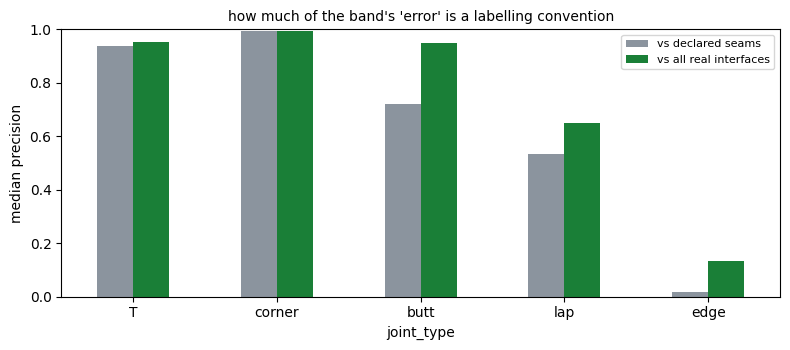

Recall is 1,00 under both scorings - the band always contains the seam.
Where the two precisions differ, the gap is the convention. Where they do not,
the lost precision is the band's WIDTH, which no relabelling fixes.


In [12]:
fig, ax = plt.subplots(figsize=(8, 3.6))
piv = fp.groupby("joint_type")[["prec_declared", "prec_all"]].median().reindex(order)
piv.plot.bar(ax=ax, color=["#8b949e", "#1a7f37"], rot=0)
ax.set_ylabel("median precision"); ax.set_ylim(0, 1)
ax.legend(["vs declared seams", "vs all real interfaces"], fontsize=8)
ax.set_title("how much of the band's 'error' is a labelling convention", fontsize=10)
plt.tight_layout(); plt.show()

print("Recall is 1,00 under both scorings - the band always contains the seam.")
print("Where the two precisions differ, the gap is the convention. Where they do not,")
print("the lost precision is the band's WIDTH, which no relabelling fixes.")

## The density anomaly on the raw band

A seam is not just a curvature feature. **Two surfaces converge at a fold, so a fold seam
sits in a density surplus; a coplanar seam is a gap in a flat surface, so it sits in a
deficit.** One measurement, and its *sign* says which family the seam belongs to.

The catch, and the reason this was invisible until now: `voxel_downsample` makes density
uniform by construction. Measured after the voxel merge the answer is 1,0 everywhere. So
`detect` now computes it on `band_raw` — the band *before* the merge — and carries it
alongside as `band_density`.

**Exposed, not yet acted on.** The detection path is unchanged; `band` is still
`voxel_downsample(band_raw, voxel_mm)` exactly as before. This cell is here to see whether
the signal is worth using before anything is built on it.

In [13]:
from baselines.metrics import distance_to_polylines

bins = [(0.0, 0.25), (0.25, 0.5), (0.5, 1.0), (1.0, 1.5), (1.5, 2.5)]
prof = {}
for d in SUBSET:
    o = run(d)
    if o is None:
        continue
    r_, gt_, jt = o[1], o[3], o[0]["joint_type"]
    if not len(r_.band_raw):
        continue
    R = o[0]["radius_mm"]
    dg = distance_to_polylines(r_.band_raw, gt_)
    row_ = prof.setdefault(jt, {b: [] for b in bins})
    for b in bins:
        m = (dg >= b[0] * R) & (dg < b[1] * R)
        if m.any():
            row_[b].append(float(r_.band_density[m].mean()))

dens = pd.DataFrame(
    {f"{a}-{b}R": {jt: np.mean(v[(a, b)]) if v[(a, b)] else np.nan
                   for jt, v in prof.items()} for a, b in bins}
).reindex([j for j in ["T", "corner", "butt", "lap", "edge"] if j in prof])
print("local density / band median, vs distance from the true seam")
print(dens.round(2))

local density / band median, vs distance from the true seam
        0.0-0.25R  0.25-0.5R  0.5-1.0R  1.0-1.5R  1.5-2.5R
T            1.13       1.03      0.91      1.01      0.82
corner       1.20       1.07      0.84      0.67       NaN
butt         1.09       0.99      0.92      0.91       NaN
lap          1.04       0.97      0.96      0.98      1.01
edge         0.56       0.57      0.58      0.45      0.49


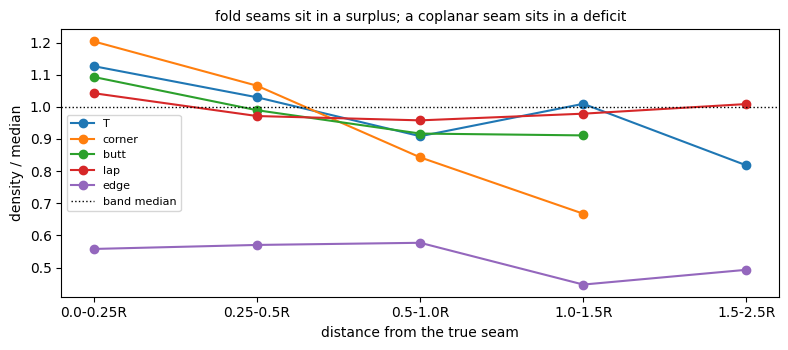

Read the SIGN, not just the magnitude: everything above 1,0 at the seam is a fold
(T, corner, butt, lap); edge sits below 1,0 because its seam is a gap, not a fold.


In [14]:
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(dens.columns))
for jt, r_ in dens.iterrows():
    ax.plot(x, r_.values, "o-", label=jt)
ax.axhline(1.0, c="k", ls=":", lw=1, label="band median")
ax.set_xticks(x); ax.set_xticklabels(dens.columns)
ax.set_xlabel("distance from the true seam"); ax.set_ylabel("density / median")
ax.legend(fontsize=8)
ax.set_title("fold seams sit in a surplus; a coplanar seam sits in a deficit", fontsize=10)
plt.tight_layout(); plt.show()

print("Read the SIGN, not just the magnitude: everything above 1,0 at the seam is a fold")
print("(T, corner, butt, lap); edge sits below 1,0 because its seam is a gap, not a fold.")

## The oracle ablation

`weld_require_cross_object` keeps an edge point only if a point of a **different object**
lies within `R`. It is what collapses the original's 266×211×134 mm blob to a line, and it
is not available at runtime: object membership comes from the registered CAD assembly.

So this is the honest point-cloud-only number, next to the published one. Any gap between
the two is the part of the method's performance that CAD registration is paying for.

In [15]:
abl = []
for d in [d for jt in CORPUS for d in CORPUS[jt][:6]]:
    for oracle in (True, False):
        o = run(d, view="single", cross_object=oracle)
        if o:
            abl.append({**o[0], "arm": "CAD oracle" if oracle else "cloud only"})
abl = pd.DataFrame(abl)
print(abl.groupby("arm")[["chamfer", "precision", "recall", "f1",
                          "n_clusters"]].median().round(3))

            chamfer  precision  recall     f1  n_clusters
arm                                                      
CAD oracle    3.202      0.993   0.766  0.789         1.0
cloud only   53.764      0.265   0.867  0.372         3.0


## Open questions

1. **Act on the density anomaly.** It is weaker than `V` (a 1,05–1,26× surplus), so it
   belongs as a clustering weight or a tie-breaker, not as a detector — and it has to run on
   the raw band, since the voxel merge erases it.
2. **Coplanar seams are the same problem read backwards.** Edge joints and butt centrelines
   both sit in a density *deficit*. That unifies two cases previously treated separately.
3. **The CAD oracle is still doing most of the work** (F1 0,75 → 0,03 without it). Two arms,
   not a replacement — and `lit-lobb` now gives this the strongest possible framing: its
   published pipeline obtains the *same input* from a trained K-Net at 97,35% mIoU, and
   collapses by the same factor without it (0,83 → 0,02). The dependency is a property of
   the problem.
4. ~~Is the predicted window the right window?~~ **Answered.** The upper bound was `t/2`,
   not `t` — the ball's diameter bridges the plate, not its radius. Measured paired above;
   `upper="thickness"` keeps the old claim reachable.
5. **No noise yet.** Every run here is on the clean cloud; `run(..., noisy=True)` applies
   the analytic stereo model.
6. **Direction-aware clustering was largely absorbed by the window correction.** Under the
   old bound it was a ~15× win on exact seam counts; under the corrected bound the band is
   already thin, the gain shrinks to noise (8% → 10% exact above) and it over-fragments —
   worst on edge, whose band has no direction structure. Keep it off by default; revisit
   only if a fat-band regime (large `R`, coarse density) returns.